In [1]:
import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np

conn = mysql.connector.connect(
    host = 'localhost',
    user = 'root',
    password = 'malcolmX@1974',
    database = 'purchases')

cur = conn.cursor()



# Which video categories have the highest average views, and engagement rate

In [2]:
query = """ SELECT category, round(avg(views), 2) as views, avg(engagement_score) FROM youtube_analysis.youtube
group by category
order by views desc
limit 5 """

cur.execute(query)

data = cur.fetchall()
data
df = pd.DataFrame(data, columns = ["Category", "Avg Views", "Avg engagement score"])
df

,Category,Avg Views,Avg engagement score
0,Sports,4649919.75,7.591209
1,Shows,4633420.31,7.127119
2,Gaming,4277080.74,7.602759
3,Shorts,4206890.79,7.494265
4,Entertainment,3777913.81,7.526603


# Which video categories showed the highest year-over-year growth in views

In [3]:
query = """ SELECT year, title, category, views FROM (
select *, row_number() over(partition by year order by views desc) as a from youtube_analysis.youtube) t where a = 1 """

cur.execute(query)

data = cur.fetchall()
data

df = pd.DataFrame(data, columns = ["year", "video title", "category", "views"])
df

,year,video title,category,views
0,2020,This fast food is UNREAL,Comedy,425349281
1,2021,This gadgets is UNREAL,People & Blogs,604971722
2,2022,I Spent $10000 on gadgets,Entertainment,1043733215
3,2023,Top 10 Football Moments of 2024,Sports,728220800
4,2024,Kai Cenat plays Minecraft for the first time,Gaming,2000000000
5,2025,This luxury items is UNREAL,Comedy,287984342
6,2026,I Tested Neuralink For 30 Days,Science & Technology,160839225


# Which categories consistently underperform in views and engagement across years?

In [4]:
query = """ with yearly as (
select
year,
category,
sum(views) as Views from youtube_analysis.youtube
group by year, category), 

growth as (
select 
year, category, Views,
lag(Views) over (partition by category order by year) as prev_views from yearly),
growth_calc as (
select * , (Views - prev_views) * 100.0/ nullif(prev_views, 0) as yoy_growth from growth),
category_summary as (
select 
category, 
avg(Views) as avg_views,
avg(yoy_growth) as avg_growth
from growth_calc
group by category)

select category,
avg_views,
avg_growth
from category_summary
order by avg_views asc, avg_growth asc 
limit 5 """

cur.execute(query)

data = cur.fetchall()
data

df = pd.DataFrame(data, columns = ["Category", "Avg Views", "Avg growth rate"])
df

,Category,Avg Views,Avg growth rate
0,Nonprofits & Activism,72387855.4286,-6.010265000
1,Autos & Vehicles,81566436.2857,107.303328333
2,Travel & Events,83887624.0000,112.724640000
3,Pets & Animals,86478760.4286,239.372125000
4,Education,109248851.8571,29.486315000


# Calculate YoY growth rate of views

In [5]:
query = """ with a as(select `year` as years,
sum(`views`) as Views from youtube_analysis.youtube
group by years order by years) 

select years, ((Views - lag(Views, 1) over(order by years))/
lag(Views, 1) over(order by years)) * 100 from a """

cur.execute(query)


data = cur.fetchall()
data

df = pd.DataFrame(data, columns = ["year", "%growth rate"])
df

,year,%growth rate
0,2020,None
1,2021,19.5684
2,2022,14.9437
3,2023,-15.4664
4,2024,59.1867
5,2025,-37.3055
6,2026,-68.5058


# What publishing days trend fastest?

In [6]:
query = """ SELECT day_of_week ,count(day_of_week) as frequency FROM youtube_analysis.youtube
group by day_of_week
order by frequency desc
limit 1 """

cur.execute(query)

data = cur.fetchall()
("The fastest trending day and its number of trends are", data[0])

('The fastest trending day and its number of trends are', ('Friday', 1459))

# Analyze correlation between video duration and performance matrics (views)

In [7]:
query = """ select 
CASE 
	when duration_seconds between 15 and 6777 then 'Short'
    when duration_seconds between 6778 and 13554 then 'Medium'
    else 'Long'
END as duration_group,
count(*) as total_videos,
round(avg(views), 2) as avg_views,
round(avg(likes), 2) as avg_likes
from youtube_analysis.youtube
group by duration_group
order by avg_views desc;
 """
cur.execute(query)
data = cur.fetchall()
data
df = pd.DataFrame(data, columns = ["duration_group","total videos", "average views", "average likes"])
df


,duration_group,total videos,average views,average likes
0,Short,9974,3117772.88,164544.71
1,Medium,25,2979309.24,106821.28
2,Long,1,189012.00,5341.00


# Which channels contribute disproportionately to total views and engagement?

In [8]:
query = """ select channel_name, sum(views) as total_views, round(
sum(views) * 100.0 / sum(sum(views)) over(), 2) as percentage_contribution from youtube_analysis.youtube
group by channel_name
order by percentage_contribution desc
limit 5 """

cur.execute(query)
data = cur.fetchall()
data

df = pd.DataFrame(data, columns = ["channel name", "total views", "%views"])
df

,channel name,total views,%views
0,DarkNetwork,2002166859,6.42
1,SunHub,1294805065,4.15
2,WildNetwork,1054014618,3.38
3,MoonTV,774602717,2.48
4,ProShorts,750182430,2.41


# Which countries have the highest engagement rate relative to total views?

In [9]:
query = """ SELECT trending_country, avg(views), round(max(engagement_score), 2) as engagement FROM youtube_analysis.youtube
group by trending_country
order by engagement desc
limit 5 """
cur.execute(query)
data = cur.fetchall()
data

df = pd.DataFrame(data, columns = ["Country", "avg views", "engagement score"])
df

,Country,avg views,engagement score
0,JP,3759462.6725,28.18
1,IN,4052083.8173,28.13
2,FR,2107511.6957,25.05
3,VN,1169909.2922,24.85
4,GB,2900274.3823,24.21


# Does higher view count strogly correlate with higher engagement or are diminishing returns?


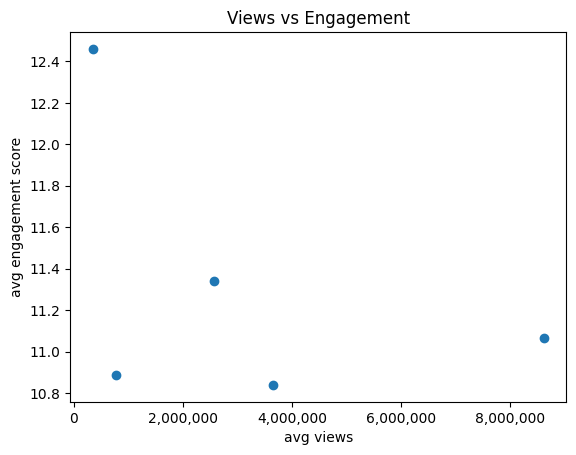

In [10]:
query = """ select channel_name, avg(views), avg(engagement_score) as engagement from youtube_analysis.youtube
group by channel_name
order by engagement desc
limit 5 """
cur.execute(query)

data = cur.fetchall()
data

df = pd.DataFrame(data, columns = ["channel name", "avg views", "avg engagement score"])
df

plt.scatter(df["avg views"],
           df["avg engagement score"])
plt.xlabel("avg views")
plt.ylabel("avg engagement score")
plt.title("Views vs Engagement")

plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.show()

# Year-over-year Growth Trend Analysis of Video Categories

In [15]:
df = pd.read_csv("C:/Users/USER/Downloads/WORK/Youtube vids.csv")
df
cat_year = (
    df.groupby(['category','year'])['views']
    .sum()
    .reset_index()
)
print(cat_year)

cat_year['prev_views'] = (
    cat_year.groupby('category')['views'].shift(1)
)
print(cat_year[['category','year','views','prev_views']])

cat_year['growth_rate'] = ((cat_year['views'] - cat_year['prev_views'])/ cat_year['prev_views']) * 100
print(cat_year[['category','growth_rate']])
df = pd.DataFrame(cat_year['growth_rate'])
df

avg_growth = (
    cat_year.groupby('category')['growth_rate']
    .mean()
    .reset_index()
)
print(avg_growth)
df = pd.DataFrame(avg_growth)
df

             category  year      views
0    Autos & Vehicles  2020   44526652
1    Autos & Vehicles  2021  262222765
2    Autos & Vehicles  2022   94066513
3    Autos & Vehicles  2023   65711247
4    Autos & Vehicles  2024   16452026
..                ...   ...        ...
114   Travel & Events  2022   40931841
115   Travel & Events  2023   81589218
116   Travel & Events  2024   49109949
117   Travel & Events  2025  332463237
118   Travel & Events  2026    6601972

[119 rows x 3 columns]
             category  year      views   prev_views
0    Autos & Vehicles  2020   44526652          NaN
1    Autos & Vehicles  2021  262222765   44526652.0
2    Autos & Vehicles  2022   94066513  262222765.0
3    Autos & Vehicles  2023   65711247   94066513.0
4    Autos & Vehicles  2024   16452026   65711247.0
..                ...   ...        ...          ...
114   Travel & Events  2022   40931841   12887467.0
115   Travel & Events  2023   81589218   40931841.0
116   Travel & Events  2024   49109949  

,category,growth_rate
0,Autos & Vehicles,107.303328
1,Comedy,30.336300
2,Education,29.486315
3,Entertainment,73.071670
4,Film & Animation,129.967128
5,Gaming,53.977025
6,Howto & Style,18.719998
7,Music,12.132360
8,News & Politics,169.362070
9,Nonprofits & Activism,-6.010264
